# **Import Libraries**

In [1]:
# Import the required libraries
import yaml
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Tuple, Any, Dict, List

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier as RFC
from xgboost import XGBClassifier as XGB
from catboost import CatBoostClassifier as CBC
from sklearn.metrics import recall_score, classification_report, ConfusionMatrixDisplay, precision_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

import mlflow
import mlflow.sklearn

# define project root
PROJECT_ROOT = Path().resolve().parent

# **Prepare Load & Update Config**

In [2]:
def load_config(config_path: str) -> dict:
    """
    Load the configuration file.

    Parameters:
    -----------
    config_path (str): The path to the configuration file.

    Returns:
    --------
    config (dict): The loaded configuration as a dictionary.
    """
    try:
        with open(config_path, 'r') as file:
            config = yaml.safe_load(file)
        if config is None:
            raise ValueError("Configuration file is empty.")
        
    except FileNotFoundError:
        raise FileNotFoundError(f"Configuration file not found at: {config_path}")
    
    except yaml.YAMLError as e:
        raise ValueError(f"Error parsing YAML file: {e}")
    
    return config

In [3]:
def update_config(key: str, value: str, config_path: str) -> dict:
    """
    Update a specific key-value pair in the config file.
    
    Parameters:
    -----------
    key (str): The key to update in the config file.
    value (str): The new value to set for the specified key.
    config_path (str): The path to the configuration file.

    Returns:
    --------
    config (dict): The updated configuration as a dictionary.
    """

    # load config
    config = load_config(config_path)
    config[key] = value

    # open config file and write the updated config
    with open(config_path, 'w') as file:
        yaml.dump(config, file)
    
    print(f"Config updated: {key} set to {value}")

    # reload config
    return load_config(config_path)

In [4]:
# load config
config = load_config(config_path=PROJECT_ROOT/'config/config.yaml')
config

{'ALL_COLS': ['Age',
  'Attrition',
  'BusinessTravel',
  'DailyRate',
  'Department',
  'DistanceFromHome',
  'Education',
  'EducationField',
  'EnvironmentSatisfaction',
  'Gender',
  'HourlyRate',
  'JobInvolvement',
  'JobLevel',
  'JobRole',
  'JobSatisfaction',
  'MaritalStatus',
  'MonthlyIncome',
  'MonthlyRate',
  'NumCompaniesWorked',
  'OverTime',
  'PercentSalaryHike',
  'PerformanceRating',
  'RelationshipSatisfaction',
  'StockOptionLevel',
  'TotalWorkingYears',
  'TrainingTimesLastYear',
  'WorkLifeBalance',
  'YearsAtCompany',
  'YearsInCurrentRole',
  'YearsSinceLastPromotion',
  'YearsWithCurrManager'],
 'CAT_COLS': ['BusinessTravel',
  'Department',
  'Education',
  'EducationField',
  'Gender',
  'JobRole',
  'MaritalStatus',
  'OverTime'],
 'NUM_COLS': ['Age',
  'DailyRate',
  'DistanceFromHome',
  'EnvironmentSatisfaction',
  'HourlyRate',
  'JobInvolvement',
  'JobLevel',
  'JobSatisfaction',
  'MonthlyIncome',
  'MonthlyRate',
  'NumCompaniesWorked',
  'Percen

# **Deserialize Object**

In [5]:
# define deserialize object function
def deserialize_object(path: str) -> Any:
    """
    Deserialize the object into specified path.

    Parameters:
    -----------
    path (str) : The path to deserialize the object.

    Returns:
    --------
    object (Any) : Any object will be deserialized.
    """

    obj = joblib.load(path)
    return obj

In [6]:
# load all train and test serialized
X_train = deserialize_object(path=PROJECT_ROOT/'data'/'interim'/'X_train.pkl')
y_train = deserialize_object(path=PROJECT_ROOT/'data'/'interim'/'y_train.pkl')
X_test = deserialize_object(path=PROJECT_ROOT/'data'/'interim'/'X_test.pkl')
y_test = deserialize_object(path=PROJECT_ROOT/'data'/'interim'/'y_test.pkl')

In [7]:
X_train.dtypes.value_counts()

int64     22
object     8
Name: count, dtype: int64

In [8]:
X_train.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1194,47,Travel_Rarely,1225,Sales,2,Master,Life Sciences,2,Female,47,...,3,3,3,29,2,3,3,2,1,2
128,22,Travel_Rarely,594,Research & Development,2,Below College,Technical Degree,3,Male,100,...,3,3,1,3,2,3,2,1,2,1
810,46,Travel_Rarely,406,Sales,3,Below College,Marketing,1,Male,52,...,3,4,1,23,3,3,12,9,4,9
478,25,Travel_Rarely,622,Sales,13,Below College,Medical,2,Male,40,...,3,3,0,7,1,3,7,4,0,6
491,43,Travel_Frequently,1001,Research & Development,9,Doctor,Medical,4,Male,72,...,3,2,1,10,3,3,8,7,4,7


# **Preprocessing**

In [9]:
# build preprocessing pipeline defined function

def build_pipeline() -> Tuple[Pipeline, Pipeline]:
    """
    Build numerical and categorical pipeline.
    """

    # build numerical features pipeline
    num_pipeline = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    cat_pipeline = Pipeline(steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    return num_pipeline, cat_pipeline

def build_preprocessing(num_pipe, cat_pipe):
    # combine numerical and categorical pipeline
    preprocessor = ColumnTransformer(transformers=[
        ('cat', cat_pipe, config['CAT_COLS']),
        ('num', num_pipe, config['NUM_COLS'])
    ])
    
    return preprocessor

In [10]:
# build the preprocessor
num_pipeline, cat_pipeline = build_pipeline()
preprocessor = build_preprocessing(num_pipe=num_pipeline, cat_pipe=cat_pipeline)

# **Modeling**

## **1. Baseline Model**

In [11]:
# define function to build baseline model
def build_baseline(X_train: pd.DataFrame, y_train: pd.Series) -> Any:
    """
    Build and train a baseline DummyClassifier using a stratified strategy.

    Parameters
    ----------
    X_train : np.ndarray
        Training features.
    y_train : np.ndarray
        Training labels.

    Returns
    -------
    recall_base: Any
        Recall score resulted from y_pred and y_train.
    """
    
    # create baseline object
    base_model = DummyClassifier(strategy='stratified')

    # fit object to train data
    base_model.fit(X_train, y_train)

    # predict train data
    y_pred = base_model.predict(X_train)

    # calculate baseline recall
    recall_base = recall_score(y_train, y_pred)

    return recall_base

In [12]:
# build baseline model
recall_base = build_baseline(X_train=X_train, y_train=y_train)
print('Recall Baseline:', recall_base)

Recall Baseline: 0.16842105263157894


## **2. Fit and Predict CV-Train Models**

In [13]:
# build cv-train model
def build_cv_train(
        estimator: Any,
        preprocessor: Any,
        params: Dict[str, Any],
        X_train: pd.DataFrame,
        y_train: pd.Series
) -> Tuple[Any, Any, Any, Any, Any]:
    """
    Perform cross-validated model training with preprocessing and SMOTE pipeline.
    Evaluates the best model on training data and returns predictions + best model.

    Parameters
    ----------
    estimator : Any
        Machine learning estimator to train.
    preprocessor : Any
        Preprocessing transformer.
    params : dict
        Hyperparameter search space for RandomizedSearchCV.
    X_train : np.ndarray
        Training input features.
    y_train : np.ndarray
        Training labels.
    is_smote : bool
        Option whether using smote or non-smote in fitting the models

    Returns
    -------
    tuple
        best_model : Any  
            The chosen best model based on recall train and recall cv.
        recall_train : Any
            Recall scores based on fit train fold.
        recall_cv : Any
            Recall scores based on fit validation fold (test).    
    """

    model = ImbPipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=config['RANDOM_STATE'])),
        ('model', estimator)
    ])

    # fit and cv train model
    cv_model = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        return_train_score=True,
        n_iter=config['N_ITER'],
        scoring={
            'recall': 'recall',
            'precision': 'precision'
        },
        refit='recall',
        cv=config['N_CV'],
        n_jobs=config['N_JOBS']
    )

    cv_model.fit(X_train, y_train)

    # evaluate models
    recall_train = cv_model.cv_results_['mean_train_recall'].max()
    recall_cv = cv_model.cv_results_['mean_test_recall'].max()
    precision_train = cv_model.cv_results_['mean_train_precision'].max()
    precision_cv = cv_model.cv_results_['mean_test_precision'].max()

    # pick best model
    best_model = cv_model.best_estimator_

    # save best params log
    mlflow.log_params(cv_model.best_params_)

    # save metrics log
    mlflow.log_metric('best_recall_train', recall_train)
    mlflow.log_metric('best_recall_cv', recall_cv)
    mlflow.log_metric('best_precision_train', precision_train)
    mlflow.log_metric('best_precision_cv', precision_cv)

    # save best model log
    mlflow.sklearn.log_model(best_model, name='model')

    print(f'Model {estimator.__class__.__name__} has been succesfully created.')

    return best_model, recall_train, recall_cv, precision_train, precision_cv

In [14]:
# mapping the models and their own hyperparameters
models = {
    'CBC': (CBC(), config['PARAMS_CATBOOST']),
    'RFC': (RFC(), config['PARAMS_RFC']),
    'XGB': (XGB(), config['PARAMS_XGB'])
}

# build cv-train model for each model
mlflow.set_tracking_uri(f'file://{PROJECT_ROOT}/mlruns')
mlflow.set_experiment('employee_attrition_project')

for name, (model, params) in models.items():
    with mlflow.start_run(run_name=name):
        mlflow.set_tag("model", name)
        build_cv_train(
            estimator=model,
            preprocessor=preprocessor,
            params=params,
            X_train=X_train,
            y_train=y_train
        )

/home/bagaskoroah/employee_attrition/.venv_attrition/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/23 12:58:27 INFO mlflow.tracking.fluent: Experiment with name 'employee_attrition_project' does not exist. Creating a new experiment.


0:	learn: 0.6909088	total: 75.2ms	remaining: 22.5s
1:	learn: 0.6890898	total: 88.2ms	remaining: 13.1s
2:	learn: 0.6864778	total: 101ms	remaining: 10s
3:	learn: 0.6826173	total: 111ms	remaining: 8.19s
4:	learn: 0.6807986	total: 122ms	remaining: 7.2s
0:	learn: 0.6896910	total: 74.1ms	remaining: 22.2s
5:	learn: 0.6787814	total: 152ms	remaining: 7.46s
1:	learn: 0.6866577	total: 105ms	remaining: 15.7s
0:	learn: 0.6913539	total: 103ms	remaining: 30.7s
6:	learn: 0.6759570	total: 170ms	remaining: 7.13s
2:	learn: 0.6842590	total: 113ms	remaining: 11.2s
7:	learn: 0.6740734	total: 178ms	remaining: 6.49s
1:	learn: 0.6885944	total: 109ms	remaining: 16.2s
2:	learn: 0.6851511	total: 113ms	remaining: 11.2s
3:	learn: 0.6816140	total: 128ms	remaining: 9.5s
8:	learn: 0.6713846	total: 189ms	remaining: 6.12s
4:	learn: 0.6785413	total: 141ms	remaining: 8.33s
9:	learn: 0.6696490	total: 201ms	remaining: 5.82s
5:	learn: 0.6764273	total: 158ms	remaining: 7.76s
10:	learn: 0.6660831	total: 214ms	remaining: 5.63s


2026/05/23 13:03:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model CatBoostClassifier has been succesfully created.


2026/05/23 13:04:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model RandomForestClassifier has been succesfully created.


2026/05/23 13:05:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model XGBClassifier has been succesfully created.


In [15]:
# make results summary
runs = mlflow.search_runs()
runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.best_precision_train,metrics.best_recall_cv,metrics.best_precision_cv,metrics.best_recall_train,...,params.model__min_samples_split,params.model__depth,params.model__random_strength,params.model__iterations,params.model__l2_leaf_reg,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.runName,tags.model
0,7c464a55084741279f3aff8c0b48e43e,864872648335536179,FINISHED,file:///home/bagaskoroah/employee_attrition/ml...,2026-05-23 06:04:30.473000+00:00,2026-05-23 06:05:13.688000+00:00,0.998561,0.421053,0.730447,0.903947,...,None,None,None,None,None,bagaskoroah,modeling.ipynb,NOTEBOOK,XGB,XGB
1,587160e7e4a343e09469de05b0c9ae2a,864872648335536179,FINISHED,file:///home/bagaskoroah/employee_attrition/ml...,2026-05-23 06:03:44.080000+00:00,2026-05-23 06:04:30.470000+00:00,0.936609,0.500000,0.704707,0.705263,...,15,None,None,None,None,bagaskoroah,modeling.ipynb,NOTEBOOK,RFC,RFC
2,132b6341255f4db0beb57352427b6a8b,864872648335536179,FINISHED,file:///home/bagaskoroah/employee_attrition/ml...,2026-05-23 05:58:27.395000+00:00,2026-05-23 06:03:44.078000+00:00,1.000000,0.536842,0.751125,0.975000,...,None,3,5,100,7,bagaskoroah,modeling.ipynb,NOTEBOOK,CBC,CBC


In [16]:
# obtain the best model
best_run = runs.sort_values(by='metrics.best_recall_cv', ascending=False).iloc[0]
run_id = best_run['run_id']

# load model from mlflow
best_model = mlflow.sklearn.load_model(f'runs:/{run_id}/model')
best_model

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

## **3. Predict & Evaluate Test Data**

In [29]:
def build_test(
        estimator: Any,
        X_test: pd.DataFrame,
        y_test: pd.Series,
        threshold: float = 0.5) -> Tuple[np.ndarray, float, float]:
    """
    Evaluate trained model on test data and log the recall score to MLflow.

    Parameters
    ----------
    estimator : Any
        Trained model or pipeline (already fitted) used for prediction.
    threshold : float
        Model threshold default point in 0.5.
    X_test : pd.DataFrame
        Test feature set.
    y_test : pd.Series
        Ground truth labels for test data.

    Returns
    -------
    y_pred: np.ndarray
        Series of label predicted data by estimator.
    recall_test: float
        Recall score computed on the test dataset.

    Notes
    -----
    - This function assumes that an MLflow run is already active.
    - It does not start or end an MLflow run.
    - Typically used after model selection via cross-validation.
    """

    y_pred = (estimator.predict_proba(X_test)[:, 1] >= threshold).astype(int)

    # evaluate test score
    recall_test = recall_score(y_test, y_pred)
    precision_test = precision_score(y_test, y_pred)

    # log results
    mlflow.log_metric('test_recall', recall_test)
    mlflow.log_metric('test_precision', precision_test)

    return y_pred, recall_test, precision_test

In [30]:
y_pred, recall_test, precision_test = build_test(
    estimator=best_model,
    X_test=X_test,
    y_test=y_test
)

print('Recall Score Using Test Data:', recall_test)
print('Precision Score Using Test Data:', precision_test)

Recall Score Using Test Data: 0.574468085106383
Precision Score Using Test Data: 0.4090909090909091


## **4. Threshold Tuning**

In [31]:
def threshold_tuning(estimator: Any, X_test: pd.DataFrame, y_test: pd.DataFrame) -> List:
    """
    Perform threshold tuning on a trained classification model.

    Parameters
    ----------
    estimator : Any
        Trained classification model supporting predict_proba().

    X_valid : pd.DataFrame
        Validation feature dataset.

    y_valid : pd.Series
        Validation target labels.

    Returns
    -------
    Dict[str, List]
        Dictionary containing:
        - model_name: name of the estimator
        - threshold: threshold values tested
        - metric_score: metric value at each threshold    
    """

    # copy test data so remain immutable
    X_test = X_test.copy()
    y_test = y_test.copy()

    # define threshold point
    thresh_list = np.linspace(0.01, 1, 100)

    # store each threshold performance to list of dict
    results = list()

    # define y prob
    y_prob = estimator.predict_proba(X_test)[:, 1]

    # iterate every performance on each threshold point
    for t in thresh_list:
        y_pred_prob = (y_prob >= t).astype(int)
        recall_score = classification_report(y_test, y_pred_prob, output_dict=True)['1']['recall']
        precision_score = classification_report(y_test, y_pred_prob, output_dict=True)['1']['precision']

        results.append({
            'model': estimator.__class__.__name__,
            'threshold': float(t),
            'recall': recall_score,
            'precision': precision_score
        })

    return results

In [32]:
# generate model performance on each threshold
catboost_thresh_perf = threshold_tuning(
    estimator=best_model,
    X_test=X_test,
    y_test=y_test
)

/home/bagaskoroah/employee_attrition/.venv_attrition/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bagaskoroah/employee_attrition/.venv_attrition/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bagaskoroah/employee_attrition/.venv_attrition/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

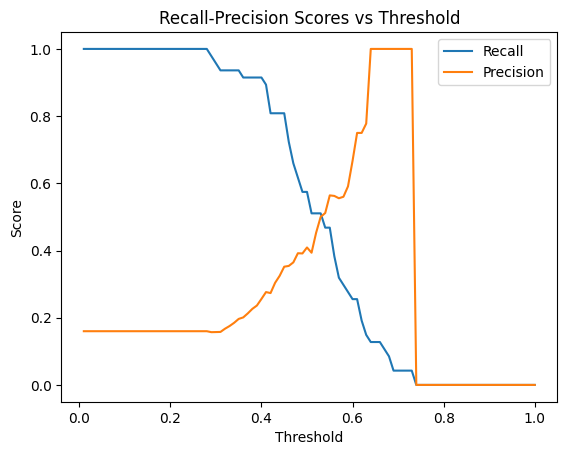

In [33]:
# plot the results
thresh_list = []
recall_list = []
precision_list = []

for perf in catboost_thresh_perf:
    thresh_list.append(perf['threshold'])
    recall_list.append(perf['recall'])
    precision_list.append(perf['precision'])

plt.plot(thresh_list, recall_list, label='Recall')
plt.plot(thresh_list, precision_list, label='Precision')
plt.title('Recall-Precision Scores vs Threshold')
plt.legend()
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.show()

I think i will be prioritizing to choose threshold point that affects the better recall scores because the effort of retaining talent will help to reduce the cost affected by letting the talents away and recruiting new talents. So, i will take threshold at 0.35 point to maximize the recall but somehow compromise the cost of false positive given by worse precision score.

## **5. Predict & Evaluate on Test Data Using New Threshold**

In [40]:
# define a function to serialize any object
def serialize_object(path: str, obj: Any) -> None:
    """ 
    Serialize the object into specified path.

    Parameters:
    -----------
    path (str): The path to save the serialized object.
    obj (Any): The object to be serialized.

    Returns:
    --------
    None
    """
    # save the object to the specified path
    joblib.dump(value=obj, filename=path)
    print(f'Saving object. . . .')
    print(f'Object serialized successfully to: {path}')

# save the best model
serialize_object(path=PROJECT_ROOT/'models'/'best_model.pkl', obj=best_model)

Saving object. . . .
Object serialized successfully to: /home/bagaskoroah/employee_attrition/models/best_model.pkl


In [41]:
# save threshold to the config file
config = update_config(
    key='BEST_THRESHOLD_POINT',
    value=0.45,
    config_path=PROJECT_ROOT/'config/config.yaml'
)

Config updated: BEST_THRESHOLD_POINT set to 0.45


In [42]:
# predict & evaluate on 0.35 threshold point
y_pred_tuned, recall_test_tuned, precision_test_tuned = build_test(
    estimator=best_model,
    X_test=X_test,
    y_test=y_test,
    threshold=config['BEST_THRESHOLD_POINT']
)

print('Recall Score Using Test Data:', recall_test_tuned)
print('Precision Score Using Test Data:', precision_test_tuned)

Recall Score Using Test Data: 0.8085106382978723
Precision Score Using Test Data: 0.35185185185185186
